# Polygon conservative regridder — unstructured mesh + save/load

When cells are arbitrary polygons (ICON triangles, MPAS hexagons, country shapes for
regional aggregation) use `ConservativeRegridder.from_polygons`. The shapely STRtree
handles any polygon layout.

This notebook builds a synthetic Voronoi hex-like mesh with scipy, regrids a structured
source onto it, then persists the regridder so subsequent runs skip the weight build.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.spatial import Voronoi
import shapely

import xarray_regrid  # noqa: F401
from xarray_regrid import ConservativeRegridder, polygons_from_coords

## Build a hex-like Voronoi mesh

Jittered grid points → Voronoi → clip to the region of interest. Real workflows
would load a pre-built mesh (UGRID, ICON, etc.); the point here is that
`from_polygons` needs only a 1D array of shapely polygons.

In [2]:
def voronoi_mesh(n_points, bbox, seed=0):
    rng = np.random.default_rng(seed)
    x0, y0, x1, y1 = bbox
    side = int(np.sqrt(n_points))
    xs = np.linspace(x0, x1, side); ys = np.linspace(y0, y1, side)
    pts = np.column_stack([np.repeat(xs, side), np.tile(ys, side)])
    pts += rng.normal(scale=(x1 - x0) / side * 0.25, size=pts.shape)
    halo = np.array([
        [2*x0 - x1, 2*y0 - y1], [2*x1 - x0, 2*y0 - y1],
        [2*x0 - x1, 2*y1 - y0], [2*x1 - x0, 2*y1 - y0],
    ])
    vor = Voronoi(np.concatenate([pts, halo]))
    clip = shapely.box(x0, y0, x1, y1)
    polys, centers = [], []
    for i in range(len(pts)):
        r = vor.regions[vor.point_region[i]]
        if not r or -1 in r:
            continue
        p = shapely.intersection(shapely.Polygon(vor.vertices[r]), clip)
        if p.is_empty or p.geom_type != "Polygon":
            continue
        polys.append(p); centers.append(pts[i])
    return np.array(polys, dtype=object), np.array(centers)

bbox = (-120, -50, 120, 50)
mesh_polys, mesh_centers = voronoi_mesh(n_points=400, bbox=bbox)
print(f"{len(mesh_polys)} cells in the mesh")

398 cells in the mesh


## Source — structured lat/lon field

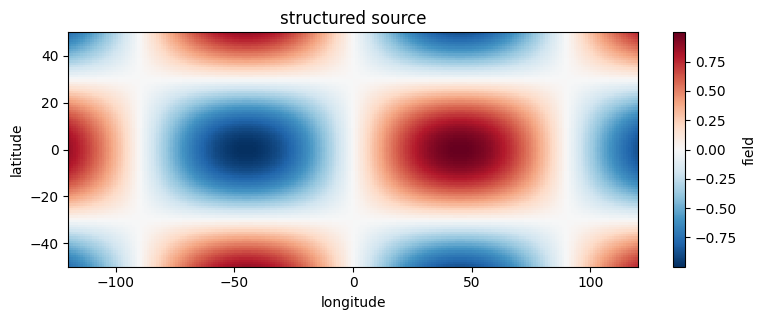

In [3]:
lat_s = np.linspace(-50, 50, 100, endpoint=False) + 0.5
lon_s = np.linspace(-120, 120, 240, endpoint=False) + 0.5
Lo, La = np.meshgrid(lon_s, lat_s)
field = np.sin(np.deg2rad(Lo) * 2) * np.cos(np.deg2rad(La) * 3)
src = xr.DataArray(
    field,
    dims=("latitude", "longitude"),
    coords={"latitude": lat_s, "longitude": lon_s},
    name="field",
)
src.plot(figsize=(8, 3.3), cmap="RdBu_r", center=0)
plt.title("structured source")
plt.tight_layout()

## Regrid structured → mesh with `from_polygons`

We convert the structured grid into a flat polygon list via `polygons_from_coords`
(row-major, y-slow / x-fast) and flatten the data the same way. Output is a 1D
array indexed by mesh cell.

In [4]:
grid_polys = polygons_from_coords(lon_s, lat_s)

rgr = ConservativeRegridder.from_polygons(
    grid_polys, mesh_polys,
    source_dim="src_cell",
    target_dim="cell",
)
print(rgr)

src_flat = xr.DataArray(src.values.ravel(), dims=("src_cell",))
mesh_vals = rgr.regrid(src_flat)
mesh_vals

ConservativeRegridder(src_dims=('src_cell',), dst_dims=('cell',), 398x24000, nnz=31875)


<xarray.DataArray (cell: 398)> Size: 3kB
array([-0.6828435 , -0.52020535, -0.34043656, -0.05049317, -0.12985816,
        0.31035596,  0.55679515,  0.73714634,  0.79715029,  0.75440137,
        0.73846747,  0.56186966,  0.50518574,  0.24205725,  0.02472535,
       -0.17479924, -0.41243175, -0.62933553, -0.68358687, -0.48097563,
       -0.29176974, -0.24634718, -0.01120315,  0.14080408,  0.089748  ,
        0.33788694,  0.55161779,  0.47166168,  0.67826547,  0.6011212 ,
        0.38839256,  0.46979398,  0.18574702,  0.31437291, -0.02156659,
       -0.06562757, -0.17649315, -0.42198051, -0.308658  , -0.02001994,
       -0.13605377, -0.09357425, -0.00459541,  0.05862798,  0.11163482,
        0.09602874,  0.05599573,  0.11830369,  0.28834433,  0.07279747,
        0.21941021,  0.05890276,  0.11421152,  0.08236516,  0.01092236,
       -0.04497362, -0.04663858, -0.0670035 , -0.21887831,  0.30405694,
        0.14758091,  0.12484246,  0.01801111,  0.01998386, -0.06958026,
       -0.22626343, -0.19633301, -0.34295916, -0.04050547, -0.31439477,
       -0.29516358, -0.23092622, -0.04689604, -0.0397324 , -0.01048109,
        0.01823587,  0.09520633,  0.2304076 ,  0.07931317,  0.59493269,
        0.42148916,  0.30936307,  0.19831751, -0.04594672, -0.19822369,
       -0.39581912, -0.55086584, -0.526165  , -0.4815598 , -0.66516286,
       -0.63227259, -0.43886083, -0.21653109, -0.27231148, -0.10094695,
        0.11938996,  0.42351928,  0.28956548,  0.47690002,  0.74804334,
...
       -0.37656809, -0.22852519, -0.04344777,  0.01792701,  0.17333448,
        0.32389057,  0.46390007,  0.6644992 ,  0.62893444,  0.48691719,
        0.45608447,  0.68040179,  0.46885146,  0.21583469,  0.00941059,
       -0.1331172 , -0.40796933, -0.3614278 , -0.52244927, -0.27981908,
       -0.27632693, -0.23998643, -0.08445465,  0.07873908,  0.07181187,
        0.06149854,  0.19158247,  0.21913798,  0.34554757,  0.30641554,
        0.0175934 ,  0.2244458 ,  0.08640918,  0.11910919,  0.00544381,
       -0.02982331, -0.2136362 , -0.10050146, -0.20911187,  0.01803716,
        0.22387688,  0.08988479,  0.06094732, -0.05726633,  0.0011813 ,
       -0.04608545, -0.185028  , -0.11268017, -0.14596539, -0.25748198,
        0.0815998 , -0.12245219, -0.09431421, -0.05502579, -0.00772848,
        0.04972775,  0.02800019,  0.16214991,  0.26727786,  0.48381549,
        0.40825614,  0.31748295,  0.06169299,  0.07942008, -0.1360152 ,
       -0.28038185, -0.35898583, -0.39069976, -0.46796485, -0.39132032,
       -0.60070257, -0.46962788, -0.3359683 , -0.24423894,  0.06888536,
       -0.05912582,  0.38349241,  0.49376074,  0.39838327,  0.58905439,
        0.56349504,  0.25152149, -0.14721418, -0.33043202, -0.50757441,
       -0.52404807, -0.76061991, -0.75971976, -0.74589083, -0.59263825,
       -0.7027589 , -0.52312689, -0.30315877, -0.00300608,  0.194532  ,
        0.29945327,  0.48218566,  0.64474778])
Coordinates:
  * cell     (cell) int64 3kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397

## Plot the regridded field on the mesh

Text(0.5, 1.0, 'regridded onto 398-cell Voronoi mesh')

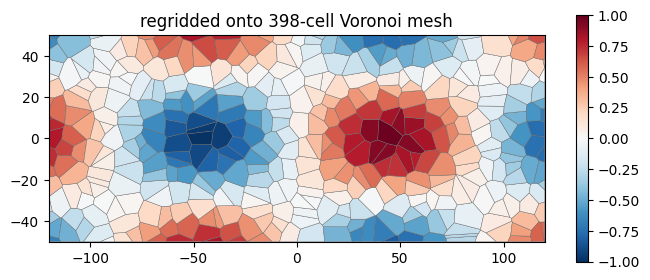

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
patches = [np.asarray(p.exterior.coords) for p in mesh_polys]
pc = PolyCollection(patches, array=mesh_vals.values, cmap="RdBu_r",
                    edgecolor="0.4", lw=0.3, clim=(-1, 1))
ax.add_collection(pc)
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.set_aspect("equal")
fig.colorbar(pc, ax=ax, shrink=0.8)
ax.set_title(f"regridded onto {len(mesh_polys)}-cell Voronoi mesh")

## Persist the regridder to netCDF

For a fixed source / target pair the weight matrix is the same forever. Persisting
it to disk lets long-running pipelines skip the (expensive) build on restart.

In [6]:
path = Path(tempfile.gettempdir()) / "mesh_regridder.nc"
rgr.to_netcdf(path)
print(f"wrote {path} ({path.stat().st_size / 1024:.1f} KB)")

# Inspect on-disk metadata (useful for provenance):
with xr.open_dataset(path) as weights:
    for k, v in weights.attrs.items():
        print(f"  {k}: {v}")

wrote /var/folders/n1/xlk9kjfn39l5q4z54rnbz4tc0000gp/T/mesh_regridder.nc (951.7 KB)
  x_coord: 
  y_coord: 
  spherical: 0
  src_dims: src_cell
  dst_dims: cell
  src_shape: 24000
  dst_shape: 398
  xarray_regrid_version: 0.4.2
  created: 2026-04-19T17:16:16.307818+00:00
  schema_version: 1
  n_dst: 398
  n_src: 24000


## Reload and apply to new data

In [7]:
rgr2 = ConservativeRegridder.from_netcdf(path)

# Apply to a new structured field of the same shape:
new_src = xr.DataArray(
    np.cos(np.deg2rad(Lo)) * np.sin(np.deg2rad(La) * 2),
    dims=("latitude", "longitude"),
    coords=src.coords,
)
out = rgr2.regrid(xr.DataArray(new_src.values.ravel(), dims=("src_cell",)))

# Sanity check: reloaded regridder produces identical output to the original.
reference = rgr.regrid(xr.DataArray(new_src.values.ravel(), dims=("src_cell",)))
print(f"max diff reloaded vs original: {float(np.abs(out.values - reference.values).max()):.2e}")

max diff reloaded vs original: 0.00e+00
